In [26]:
import os
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.stats import shapiro


# ── Configuration ──────────────────────────────────────────────────────────────
BASE_DIR = "BOULDERING_DATA/batch1/batch1_unzipped"

SENSOR_FILES = [
    "Accelerometer",
    "Gravity",
    "Gyroscope",
    "Linear Accelerometer",
    "Location",
    "Orientation",
]


In [6]:
# ── Load all runs ───────────────────────────────────────────────────────────────
runs = {}  # { run_folder_name: { sensor_name: DataFrame } }

for run_folder in sorted(os.listdir(BASE_DIR)):
    run_path = os.path.join(BASE_DIR, run_folder)
    if not os.path.isdir(run_path):
        continue

    run_data = {}
    for sensor in SENSOR_FILES:
        csv_path = os.path.join(run_path, f"{sensor}.csv")
        if os.path.exists(csv_path):
            run_data[sensor] = pd.read_csv(csv_path)
        else:
            print(f"  [missing] {run_folder} / {sensor}.csv")

    runs[run_folder] = run_data

print(f"Loaded {len(runs)} runs.")
print("Run names:", list(runs.keys())[:5], "...")


Loaded 35 runs.
Run names: ['L 1 N Y teo2026-06-05 2-06-08\u202fPM', 'L1 N Y kar 2026-06-05 2-14-58\u202fPM', 'L1 N Y kar2026-06-05 2-09-18\u202fPM', 'L1 N Y teo 2026-06-05 2-16-06\u202fPM', 'L2 N Y teo 2026-06-05 3-57-10\u202fPM'] ...


In [21]:
# Access one run's accelerometer data
df = runs["L 1 N Y teo2026-06-05 2-06-08\u202fPM"]["Accelerometer"]
print(df.head())
print(df.describe())

   Time (s)  X (m/s^2)  Y (m/s^2)  Z (m/s^2)
0  0.024534   9.798025   0.918340   3.676205
1  0.034555   9.387878   0.606389   3.968248
2  0.044576   8.911419   0.515827   3.961811
3  0.054597   8.634794   0.769999   3.829636
4  0.064619   8.827443   1.083447   3.476970
          Time (s)    X (m/s^2)    Y (m/s^2)    Z (m/s^2)
count  2287.000000  2287.000000  2287.000000  2287.000000
mean     11.478833     5.691757    -0.120851     2.670377
std       6.617490     5.143616     7.513831     2.741400
min       0.024534   -64.082490   -16.173717   -10.199789
25%       5.751679     2.298171    -5.912704     1.636023
50%      11.478822     6.807544    -0.879571     2.849774
75%      17.205986     9.074130     4.726870     3.913163
max      22.933175    32.292797    53.360885    33.702415


In [12]:
for run_name, sensors in runs.items():
    for sensor_name, df in sensors.items():
        # df is the raw DataFrame — apply outlier removal here
        print(f"{run_name} | {sensor_name}: {df.shape}")

L 1 N Y teo2026-06-05 2-06-08 PM | Accelerometer: (2287, 4)
L 1 N Y teo2026-06-05 2-06-08 PM | Gravity: (2286, 4)
L 1 N Y teo2026-06-05 2-06-08 PM | Gyroscope: (2286, 4)
L 1 N Y teo2026-06-05 2-06-08 PM | Linear Accelerometer: (2286, 4)
L 1 N Y teo2026-06-05 2-06-08 PM | Location: (18, 8)
L 1 N Y teo2026-06-05 2-06-08 PM | Orientation: (2286, 9)
L1 N Y kar 2026-06-05 2-14-58 PM | Accelerometer: (2361, 4)
L1 N Y kar 2026-06-05 2-14-58 PM | Gravity: (2360, 4)
L1 N Y kar 2026-06-05 2-14-58 PM | Gyroscope: (2360, 4)
L1 N Y kar 2026-06-05 2-14-58 PM | Linear Accelerometer: (2360, 4)
L1 N Y kar 2026-06-05 2-14-58 PM | Location: (24, 8)
L1 N Y kar 2026-06-05 2-14-58 PM | Orientation: (2360, 9)
L1 N Y kar2026-06-05 2-09-18 PM | Accelerometer: (2701, 4)
L1 N Y kar2026-06-05 2-09-18 PM | Gravity: (2701, 4)
L1 N Y kar2026-06-05 2-09-18 PM | Gyroscope: (2701, 4)
L1 N Y kar2026-06-05 2-09-18 PM | Linear Accelerometer: (2701, 4)
L1 N Y kar2026-06-05 2-09-18 PM | Location: (28, 8)
L1 N Y kar2026-06-0

In [18]:
# the function for outlier detection using Chauvenet's criterion

def chauvenet_criterion(series, c=2):
    """
    Flags outliers in a pandas Series using Chauvenet's criterion.
    Returns a boolean mask aligned to the ORIGINAL index (True = outlier).
    """
    mean = series.mean()
    std = series.std()
    N = series.notna().sum()

    if std == 0:
        return pd.Series(False, index=series.index)

    prob = series.apply(lambda x: norm.cdf(x, loc=mean, scale=std))
    prob_two_tailed = 2 * np.minimum(prob, 1 - prob)

    threshold = 1 / (c * N)

    mask = prob_two_tailed < threshold
    mask = mask.fillna(False)
    return mask

In [19]:
# Sensors and their numeric columns to check (Time column is skipped)
SENSOR_NUMERIC_COLS = {
    "Accelerometer":        ["X (m/s^2)", "Y (m/s^2)", "Z (m/s^2)"],
    "Gravity":              ["X (m/s^2)", "Y (m/s^2)", "Z (m/s^2)"],
    "Gyroscope":            ["X (rad/s)", "Y (rad/s)", "Z (rad/s)"],
    "Linear Accelerometer": ["X (m/s^2)", "Y (m/s^2)", "Z (m/s^2)"],
    "Location":             ["Latitude (°)", "Longitude (°)", "Altitude (m)",
                             "Speed (m/s)", "Horizontal Accuracy (m)"],
    "Orientation":          ["Azimuth (°)", "Pitch (°)", "Roll (°)"],
}

C = 2  # Chauvenet parameter — increase to be more conservative

# runs dict was built in the loading cell above
runs_clean = {}

for run_name, sensors in runs.items():
    runs_clean[run_name] = {}
    
    for sensor_name, df in sensors.items():
        df_clean = df.copy()
        
        # Get the numeric columns that actually exist in this CSV
        cols = [col for col in SENSOR_NUMERIC_COLS.get(sensor_name, [])
                if col in df.columns]
        
        total_outliers = 0
        for col in cols:
            mask = chauvenet_criterion(df_clean[col], c=C)
            total_outliers += mask.sum()
            # Replace outliers with NaN (to be interpolated later)
            df_clean.loc[mask, col] = np.nan
        
        runs_clean[run_name][sensor_name] = df_clean
        
        if total_outliers > 0:
            print(f"  {run_name} | {sensor_name}: {total_outliers} outliers removed")

print("\nDone. Outliers replaced with NaN.")

  L 1 N Y teo2026-06-05 2-06-08 PM | Accelerometer: 53 outliers removed
  L 1 N Y teo2026-06-05 2-06-08 PM | Gyroscope: 100 outliers removed
  L 1 N Y teo2026-06-05 2-06-08 PM | Linear Accelerometer: 74 outliers removed
  L 1 N Y teo2026-06-05 2-06-08 PM | Location: 6 outliers removed
  L1 N Y kar 2026-06-05 2-14-58 PM | Accelerometer: 19 outliers removed
  L1 N Y kar 2026-06-05 2-14-58 PM | Gyroscope: 70 outliers removed
  L1 N Y kar 2026-06-05 2-14-58 PM | Linear Accelerometer: 50 outliers removed
  L1 N Y kar 2026-06-05 2-14-58 PM | Location: 3 outliers removed
  L1 N Y kar2026-06-05 2-09-18 PM | Accelerometer: 45 outliers removed
  L1 N Y kar2026-06-05 2-09-18 PM | Gyroscope: 101 outliers removed
  L1 N Y kar2026-06-05 2-09-18 PM | Linear Accelerometer: 73 outliers removed
  L1 N Y kar2026-06-05 2-09-18 PM | Location: 4 outliers removed
  L1 N Y kar2026-06-05 2-09-18 PM | Orientation: 3 outliers removed
  L1 N Y teo 2026-06-05 2-16-06 PM | Accelerometer: 33 outliers removed
  L1 N 

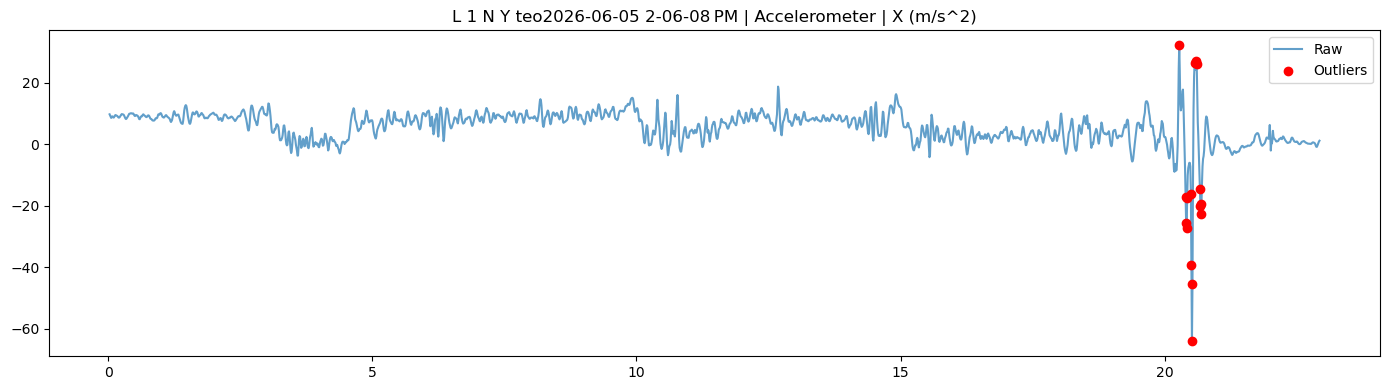

In [23]:
run = list(runs.items())[0][0]       # pick one run
sensor = "Accelerometer"
col = "X (m/s^2)"

raw = runs[run][sensor][col]
clean = runs_clean[run][sensor][col]
outlier_mask = raw.notna() & clean.isna()  # points that were replaced with NaN

plt.figure(figsize=(14, 4))
plt.plot(runs[run][sensor]["Time (s)"], raw, label="Raw", alpha=0.7)
plt.scatter(runs[run][sensor]["Time (s)"][outlier_mask],
            raw[outlier_mask], color="red", label="Outliers", zorder=5)
plt.title(f"{run} | {sensor} | {col}")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# check how much data we are removing. More than 5% removal of data might be bad
for run_name, sensors in runs.items():
    for sensor_name, df_raw in sensors.items():
        df_clean = runs_clean[run_name][sensor_name]
        cols = [col for col in SENSOR_NUMERIC_COLS.get(sensor_name, []) if col in df_raw.columns]
        for col in cols:
            n_total = df_raw[col].notna().sum()
            n_removed = df_raw[col].notna().sum() - df_clean[col].notna().sum()
            pct = 100 * n_removed / n_total if n_total > 0 else 0
            if pct > 0:
                print(f"{run_name} | {sensor_name} | {col}: {n_removed}/{n_total} removed ({pct:.1f}%)")

L 1 N Y teo2026-06-05 2-06-08 PM | Accelerometer | X (m/s^2): 16/2287 removed (0.7%)
L 1 N Y teo2026-06-05 2-06-08 PM | Accelerometer | Y (m/s^2): 18/2287 removed (0.8%)
L 1 N Y teo2026-06-05 2-06-08 PM | Accelerometer | Z (m/s^2): 19/2287 removed (0.8%)
L 1 N Y teo2026-06-05 2-06-08 PM | Gyroscope | X (rad/s): 22/2286 removed (1.0%)
L 1 N Y teo2026-06-05 2-06-08 PM | Gyroscope | Y (rad/s): 18/2286 removed (0.8%)
L 1 N Y teo2026-06-05 2-06-08 PM | Gyroscope | Z (rad/s): 60/2286 removed (2.6%)
L 1 N Y teo2026-06-05 2-06-08 PM | Linear Accelerometer | X (m/s^2): 23/2286 removed (1.0%)
L 1 N Y teo2026-06-05 2-06-08 PM | Linear Accelerometer | Y (m/s^2): 28/2286 removed (1.2%)
L 1 N Y teo2026-06-05 2-06-08 PM | Linear Accelerometer | Z (m/s^2): 23/2286 removed (1.0%)
L 1 N Y teo2026-06-05 2-06-08 PM | Location | Latitude (°): 2/18 removed (11.1%)
L 1 N Y teo2026-06-05 2-06-08 PM | Location | Longitude (°): 2/18 removed (11.1%)
L 1 N Y teo2026-06-05 2-06-08 PM | Location | Horizontal Accura

In [28]:

run = list(runs.items())[0][0]
col = "X (m/s^2)"
data = runs[run]["Accelerometer"][col].dropna()
stat, p = shapiro(data[:500])  # Shapiro-Wilk is limited to ~5000 samples
print(f"Shapiro-Wilk p={p:.4f} — {'normal' if p > 0.05 else 'NOT normal'}")


Shapiro-Wilk p=0.0000 — NOT normal


In [30]:
for run_name, sensors in runs_clean.items():
    for sensor_name, df in sensors.items():
        cols = [col for col in SENSOR_NUMERIC_COLS.get(sensor_name, [])
                if col in df.columns]
        
        # Linear interpolation over time; fall back to forward/back fill at edges
        df[cols] = df[cols].interpolate(method="linear", limit_direction="both")

print("Interpolation complete.")

Interpolation complete.
